### **TRABAJO PRÁCTICO N° 3: Redes Convolucionales, Detección de Objetos y Redes Recurrentes - Problema 3**
---
 1er cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
| Martinez Dufour, Caterina | M-7169/2   |
| Grimaldi, Damián Daniel   | G-5977/3   |
| Tapia, Fabrizio           | T-3095/3   |

**Docentes:** *Salvañá, Leandro* - *Fernández, Florencia*

### 1. Descripción del dataset
---

En este ejercicio deben construir una Red Neuronal Convolucional-Recurrente (CRNN) para reconocer comandos de voz a partir de grabaciones de audio de un segundo. El dataset contiene grabaciones pronunciadas por muchos hablantes distintos en condiciones acusticas reales (ruido de fondo, variaciones de micrófono), lo que hace que el modelado temporal de la RNN tenga valor real: comandos como down o stop son secuencias fon ́eticas con estructura temporal que una red sin memoria no puede capturar correctamente.

La arquitectura sigue un esquema many-to-one: la CNN procesa cada ventana temporal del espectrograma de forma independiente y produce un vector de características. la secuencia de esos vectores entra a la RNN, que modela cómo los patrones acústicos evolucionan en el tiempo. el  ́ultimo estado oculto se clasifica con una capa densa.

Reducción del problema: Si el entrenamiento completo resulta demasiado pesado para los recursos disponibles, pueden trabajar con un subconjunto de 4 a 6 clases (ej. yes, no, stop, go). Deben justificar la selección en el informe. Se recomienda guardar checkpoints regularmente para poder retomar el entrenamiento ante interrupciones.


#### Variables del conjunto de datos  
**Variables explicativas (features):** - Archivos de audio en formato WAV de 1 segundo de duración, con una frecuencia de muestreo de 16,000 Hz (16 kHz).
 
**Variable objetivo (target):** - Clasificación multiclase (10 clases independientes) para diferenciar entre los comandos de voz sugeridos: 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up' y 'yes'.

#### Librerias

In [4]:
!pip install librosa


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install gdown


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Librerías
import pandas as pd
import seaborn as sns
import optuna
import gdown
import zipfile
import os
import random, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
#import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix

In [8]:
import numpy as np
import tensorflow as tf
import librosa 

In [9]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

In [10]:
import shutil  # borra carpetas completas

Fijar una semilla aleatoria al inicio de cada experimento para que los resultados sean reproducibles. Esto incluye las semillas de Python, NumPy y el framework de deep learning utilizado:

In [11]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Carga del dataset
---

Para comenzar con el desarrollo, cargamos el dataset a través del enlace de Google Drive: "https://drive.google.com/file/d/1w5drimnOidgeVQu-HrdvrIeZq6u3QnM4/view". Descargamos desde el Drive el dataset de los audios en formato zip, lo descomprimimos y lo almacenamos en la carpeta "problema_3/dataset_problema3":

In [12]:
# ID de tu archivo de Drive
file_id = '1w5drimnOidgeVQu-HrdvrIeZq6u3QnM4'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = 'dataset_audios.zip' 

# Descargar el archivo
gdown.download(url, archivo_descargado, quiet=False)
# Descomprimir el archivo en la carpeta
carpeta_destino = 'problema_3/dataset_problema3'

# Creamos la carpeta si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Extraemos el contenido
try:
    with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)
    # Eliminar el archivo .zip descargado
    os.remove(archivo_descargado) 
    
except zipfile.BadZipFile:
    print("Error.")

Downloading...
From (original): https://drive.google.com/uc?id=1w5drimnOidgeVQu-HrdvrIeZq6u3QnM4
From (redirected): https://drive.google.com/uc?id=1w5drimnOidgeVQu-HrdvrIeZq6u3QnM4&confirm=t&uuid=a5082c44-1a4a-4858-848b-d6102255caf5
To: c:\Users\Usuario\cnn-rnn-objectdetection-deeplearning\problema_3\dataset_audios.zip
100%|██████████| 2.42G/2.42G [08:13<00:00, 4.90MB/s]


Clases sugeridas (10): yes, no, up, down, left, right, on, off, stop, go

In [13]:
DATA_PATH = 'problema_3/dataset_problema3' 
comandos_objetivo = ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes', 'on', 'off']
archivos_control = ['validation_list.txt', 'testing_list.txt']

for elemento in os.listdir(DATA_PATH):
    ruta_completa = os.path.join(DATA_PATH, elemento)
    
    # Borramos carpetas de palabras que no nos interesen
    if os.path.isdir(ruta_completa) and (elemento not in comandos_objetivo):
        shutil.rmtree(ruta_completa)
    # Borramos archivos de texto que no sean las listas de partición oficiales
    elif os.path.isfile(ruta_completa) and (elemento not in archivos_control):
        os.remove(ruta_completa)

In [14]:
commands = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
print("Carpetas de comandos sugeridos:", commands)

Carpetas de comandos sugeridos: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']


### 3. Preparación del audio
---

#### División del dataset

Dividimos el dataset en conjuntos de entrenamiento, validación y prueba utilizando una proporción de 80:10:10

In [15]:
test_list_oficial = []
val_list_oficial = []

with open(os.path.join(DATA_PATH, 'testing_list.txt'), 'r') as f:
    lineas_test = f.readlines()
    for line in lineas_test:
        test_list_oficial.append(line)

with open(os.path.join(DATA_PATH, 'validation_list.txt'), 'r') as f:
    lineas_val = f.readlines()
    for line in lineas_val:
        val_list_oficial.append(line)

train_files = []
val_files = []
test_files = []

# Recorremos las carpetas para armar los conjuntos definitivos
for label in commands:
    label_dir = os.path.join(DATA_PATH, label)
    for fname in os.listdir(label_dir):
        # Creamos la ruta relativa con '\n' para que coincida con el .txt
        rel_path_con_salto = f"{label}/{fname}\n"
        full_path = os.path.join(label_dir, fname)
        # Evaluamos la pertenencia usando la cadena con el salto de línea incorporado
        if rel_path_con_salto in test_list_oficial:
            test_files.append(full_path)
        elif rel_path_con_salto in val_list_oficial:
            val_files.append(full_path)
        else:
            train_files.append(full_path)

print('Training set size:', len(train_files))
print('Validation set size:', len(val_files))
print('Test set size:', len(test_files))

Training set size: 30769
Validation set size: 3703
Test set size: 4074


#### Función de carga y normalización de los audios

Esta función se encarga de cargar el audio a 16kHz asegurando que dure exactamente un segundo. aquellos audios que duren menos que este lapso de tiempo, se aplicara padding o truncado.

In [20]:
def cargar_onda_y_etiqueta(file_path):
    '''
    Esta función carga el audio a 16kHz y asegura que dure exactamente 1 segundo (16,000 muestras) mediante padding o truncado.
    '''
    audio, sr = librosa.load(file_path, sr=16000)              # Fija la frecuencia en 16000 muestras
    if len(audio) < 16000:                                     # Si dura menos de un segundo, aplica padding con ceros al final
        audio = np.pad(audio, (0, 16000 - len(audio)), mode='constant')
    elif len(audio) > 16000:                                   # Si dura más de un segundo, trunca el audio
        audio = audio[:16000]
        
    # Extraer la etiqueta normalizando la ruta
    ruta_normalizada = os.path.normpath(file_path)
    label = ruta_normalizada.split(os.path.sep)[-2]
    
    return audio, label

Visualizamos las primeras 9 ondas de audio (Waveform) del dataset de entrenamiento:

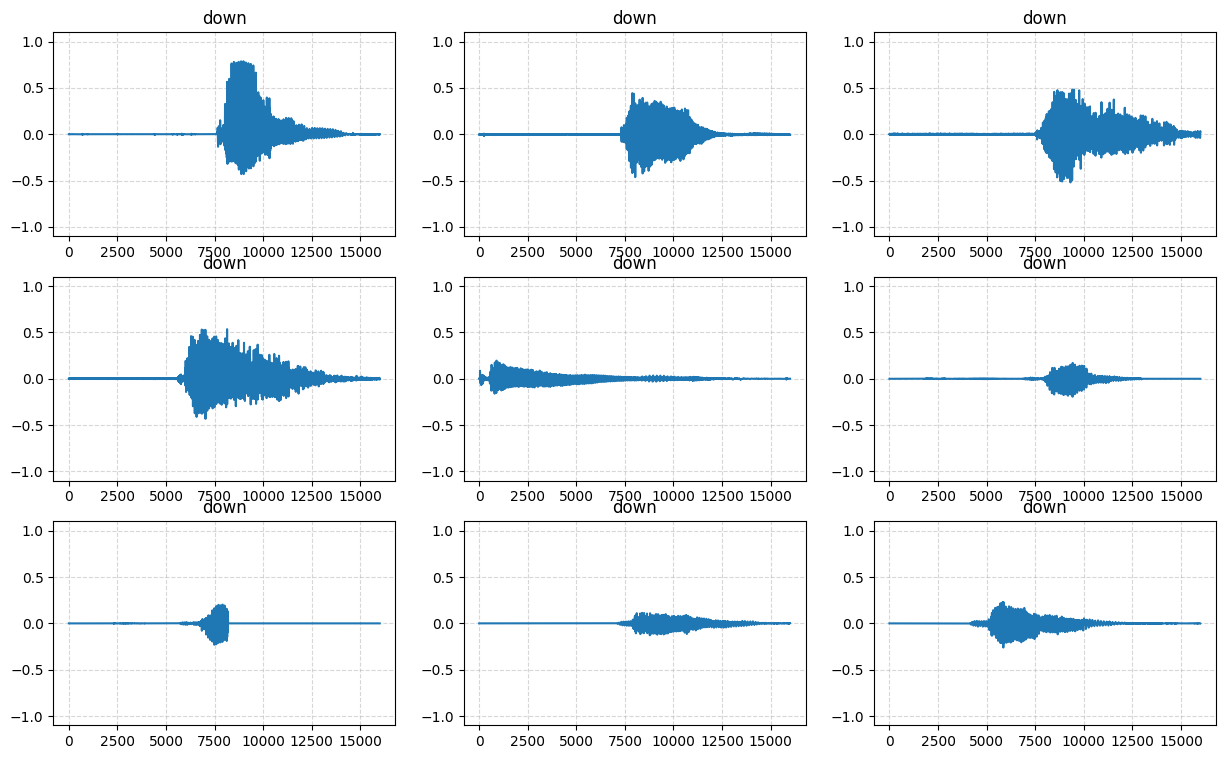

In [30]:
rows = 3
cols = 3
n = rows * cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 9))

# Se realiza el gráfico de los primeros 9 archivos del conjunto de entrenamiento
for i in range(n):
   file_path = train_files[i]
   audio, label = cargar_onda_y_etiqueta(file_path)
   r = i // cols
   c = i % cols
   ax = axes[r][c]
   ax.plot(audio)
   ax.set_ylim(-1.1, 1.1)
   ax.set_title(label)
   ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### Transformación del audio a espectogramas

Los espectrogramas de Mel representan la energía de la señal de audio en función del tiempo (eje horizontal) y la frecuencia en escala Mel (eje vertical). La escala Mel comprime las frecuencias altas y expande las bajas, imitando la percepción auditiva humana.  El color representa la intensidad de energía en decibeles (dB): colores cálidos indican alta energía, colores fríos indican baja energía o silencio.

In [36]:
def audio_a_mel(audio, sr=16000, n_mels=64, n_fft=1024, hop_length=512):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
    mel_db = librosa.power_to_db(mel, ref=np.max) # escala logaritmica (dB)
    return mel_db # shape: (F, T) = (n_mels, T)

Realizamos la normalización estándar que debe calcularse solo sobre el conjunto de entrenamiento. Para esto procesamos primero los espectogramas para obtener los valores escalares fijos

In [37]:
espectrogramas_train = []

for file in train_files:
    audio, label = cargar_onda_y_etiqueta(file) # Carga el audio a 16kHz y asegura que dure exactamente 1s.
    mel_db = audio_a_mel(audio)                 # Utilizamos la escala mel para comprimir las frecuencias altas y expandir las bajas
    espectrogramas_train.append(mel_db)         

# Calculá la media y desvío global en train
espectrogramas_train = np.array(espectrogramas_train)
mean_train = espectrogramas_train.mean()
std_train = espectrogramas_train.std()

print(f"Media de Train: {mean_train} \nDesvío de Train: {std_train}")

Media de Train: -57.210365295410156 
Desvío de Train: 19.839889526367188


Obtenemos una lista que contiene matrices (una por cada archivo de audio de train_files). Cada una de esas matrices es un Espectrograma de Mel en escala logarítmica (dB) con los siguiente:
- Frecuencia en el eje 0 (Filas): Representa las 64 bandas de frecuencia Mel (la altura de la matriz).  
- Tiempo en el eje 1 (Columnas): Representa los pasos temporales (frames) a lo largo de ese segundo de duración (el ancho de la matriz).  

Además, obtenemos la media -57.21 y el desvío estándar 19.83 del conjunto de entrenamiento.

A continuación realizamos los gráficos de 8 espectogramas (4 instancias de la misma clase y 4 instancias de clases distintas):

In [82]:
clase_down = 'down'
clase_up = 'up'
indices_down = []
indices_up = []

for idx, file_path in enumerate(train_files):
    audio_val, label_val = cargar_onda_y_etiqueta(file_path)
    
    if label_val == clase_down and len(indices_down) < 4:
        indices_down.append(idx)
    elif label_val == clase_up and len(indices_up) < 4:
        indices_up.append(idx)
        
    # Si ya encontramos 4 instancias de cada clase, finalizamos el bucle
    if len(indices_down) == 4 and len(indices_up) == 4:
        break

indices_finales = indices_down + indices_up

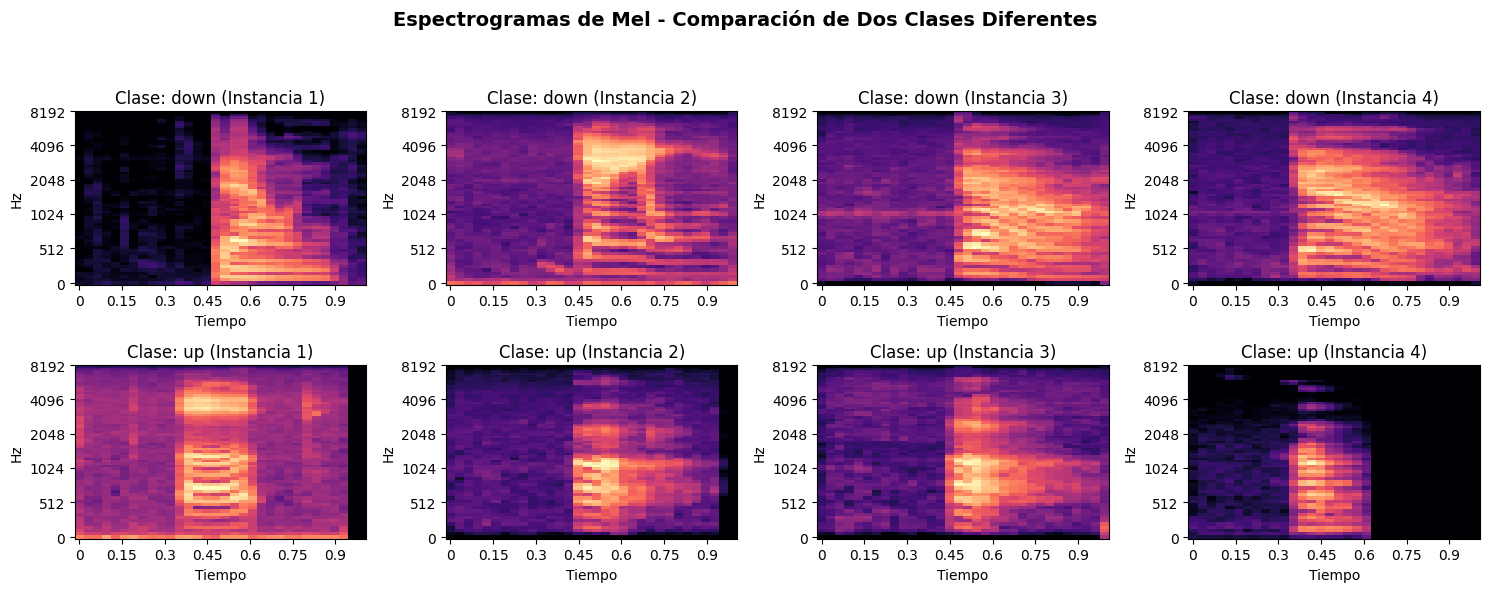

In [83]:
rows = 2
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))

for i, idx_train in enumerate(indices_finales):
    file_path = train_files[idx_train]
    audio, label = cargar_onda_y_etiqueta(file_path)
    spectrogram = espectrogramas_train[idx_train]
    
    # Posición en la grilla
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    
    # Graficar usando librosa.display sobre el objeto 'ax' 
    img = librosa.display.specshow(spectrogram, sr=16000, hop_length=512, x_axis='time', y_axis='mel', ax=ax, cmap='magma')
    
    # Título indicando el comando y el número de ejemplo (del 1 al 4)
    ax.set_title(f"Clase: {label} (Instancia {c + 1})")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Hz")

# Título general destacado para el informe
fig.suptitle('Espectrogramas de Mel - Comparación de Dos Clases Diferentes', fontsize=14, fontweight='bold')

# Ajuste inteligente de espacios para evitar superposiciones
plt.tight_layout(rect=[0, 0, 1, 0.93]) 
plt.show()

En la clase down podemos observar que la señal útil dura del 0.45 al final aproximadamente ya que antes son señales débiles. El rango de frecuencia en el que se concentra la energía del comando se mantiene mayormente por debajo de los 2048Hz a 4096Hz, aunque el gráfico muestre el límite de muestreo hasta los 8192Hz. 

En la clase up la señal útil es mucho más corta, estando compactada entre el 0.4 y 0.6 de tiempo, y el rango de frecuencia donde realmente se concentra la energía también es por debajo de los 4096Hz, localizándose con fuerza en el centro de ese intervalo temporal.

Visualmente sí se pueden distinguir espectrogramas de clases distintas a simple vista, ya que down muestra una energía estirada y continua hacia el final, mientras que up se observa como un bloque de energía central y corto que se interrumpe de golpe. Entre espectrogramas de la misma clase se observa una gran similitud, variando levemente según el ritmo o la intensidad del hablante.

### 4. pipeline CNN + LSTM (continuar)
---

In [ ]:
# Pipeline completo: mel-espectrograma con librosa y clasificador CNN + LSTM.
# entrada: Audio - encoder típico: CNN 1D / RNN  - salida: Transcripción

# --- Preprocesamiento: audio crudo -> mel-espectrograma ---
def audio_to_melspectrogram(
    path: str,
    sr: int = 16000,       # sample rate
    n_mels: int = 64,      # bins de frecuencia (mel)
    n_fft: int = 512,      # longitud de la ventana FFT
    hop_length: int = 160  # desplazamiento (10 ms a 16 kHz)
) -> np.ndarray:
    """Retorna mel-espectrograma de forma (T, n_mels)."""
    y, _ = librosa.load(path, sr=sr)
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels,
        n_fft=n_fft, hop_length=hop_length
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db.T  # transponer a (T, n_mels)

# --- Arquitectura CNN + LSTM ---
def build_audio_classifier(
    T: int,         # frames temporales
    n_mels: int,    # bins de frecuencia
    K: int,         # numero de clases
    lstm_units: int = 128
):
    inputs = tf.keras.Input(shape=(T, n_mels, 1))

    # Etapa 1: CNN sobre el eje frecuencial en cada frame
    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Conv1D(32, kernel_size=3,
                               activation="relu",
                               padding="same")
    )(inputs)
    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.GlobalAveragePooling1D()
    )(x)
    # Salida: (batch, T, 32)

    # Etapa 2: modelado temporal
    x = tf.keras.layers.LSTM(lstm_units)(x)

    # Etapa 3: clasificacion
    outputs = tf.keras.layers.Dense(
        K, activation="softmax"
    )(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Construcción y verificación del modelo recurrente/convolucional
model = build_audio_classifier(T=100, n_mels=64, K=10)
model.summary()